In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from tqdm import tqdm
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0)}')

Using device: NVIDIA GeForce RTX 5060 Ti


In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

## 1. Data Loading

Same as PostHoc GMM notebook - load hyperspectral data and treat each pixel as an independent sample.

In [3]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average across spatial dimensions
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    # Calibration
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [4]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        self.data = data
        self.labels = labels
        
        H, W, B = data.shape
        self.pixels = data.reshape(-1, B)
        
        if labels is not None:
            self.pixel_labels = labels.reshape(-1)
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [5]:
# Load data for a specific food type
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = f'../../AnomalyonFood/Dataset/{food_type}'

# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[2]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Test labels shape: (400, 512)
Number of bands: 224


In [6]:
# Create datasets
train_dataset = HSIPixelDataset(train_data)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

Training pixels: 204800
Test pixels: 204800
Spectrum dimension: 224


## 2. DGMM Module (Differentiable Gaussian Mixture Model)

**Key features:**
- Trainable mixture weights π_k
- Trainable component means μ_k
- Trainable component covariances Σ_k (diagonal for stability)
- Numerically stable log-likelihood computation

In [7]:
class DGMM(nn.Module):
    """Differentiable Gaussian Mixture Model.
    
    Trainable mixture prior for VAE latent space.
    """
    
    def __init__(self, n_components, latent_dim):
        super().__init__()
        self.n_components = n_components
        self.latent_dim = latent_dim
        
        # Mixture weights: log π_k (will be normalized by log_softmax)
        self.logits = nn.Parameter(torch.zeros(n_components))
        
        # Component means: μ_k
        self.means = nn.Parameter(torch.randn(n_components, latent_dim) * 0.1)
        
        # Component log-variances: log σ²_k (diagonal covariance)
        self.logvars = nn.Parameter(torch.zeros(n_components, latent_dim))
    
    def get_params(self):
        """Get mixture parameters in interpretable form."""
        log_pi = F.log_softmax(self.logits, dim=0)
        pi = torch.exp(log_pi)
        mu = self.means
        var = torch.exp(self.logvars)
        
        return pi, mu, var, log_pi
    
    def log_prob(self, z):
        """Compute log p(z) = log Σ_k π_k N(z | μ_k, Σ_k).
        
        Args:
            z: (batch_size, latent_dim)
        
        Returns:
            log_prob: (batch_size,)
        """
        batch_size = z.size(0)
        
        # Get parameters
        pi, mu, var, log_pi = self.get_params()
        
        # Expand dimensions for broadcasting
        # z: (batch, 1, latent_dim)
        # mu: (1, n_components, latent_dim)
        # var: (1, n_components, latent_dim)
        z_expanded = z.unsqueeze(1)  # (batch, 1, latent_dim)
        mu_expanded = mu.unsqueeze(0)  # (1, K, latent_dim)
        var_expanded = var.unsqueeze(0)  # (1, K, latent_dim)
        
        # Compute log N(z | μ_k, Σ_k) for each component
        # log N(z | μ, σ²) = -0.5 * [D*log(2π) + Σ log(σ²) + Σ (z-μ)²/σ²]
        log_2pi = np.log(2 * np.pi)
        
        log_var_sum = torch.sum(torch.log(var_expanded), dim=2)  # (batch, K)
        squared_diff = ((z_expanded - mu_expanded) ** 2) / (var_expanded + 1e-8)
        squared_diff_sum = torch.sum(squared_diff, dim=2)  # (batch, K)
        
        log_gaussian = -0.5 * (self.latent_dim * log_2pi + log_var_sum + squared_diff_sum)
        
        # Combine with mixture weights: log π_k + log N(z | μ_k, Σ_k)
        log_weighted = log_pi.unsqueeze(0) + log_gaussian  # (batch, K)
        
        # Log-sum-exp trick for numerical stability
        log_prob = torch.logsumexp(log_weighted, dim=1)  # (batch,)
        
        return log_prob
    
    def sample(self, n_samples):
        """Sample from the mixture."""
        pi, mu, var, _ = self.get_params()
        
        # Sample component assignments
        component_dist = torch.distributions.Categorical(pi)
        components = component_dist.sample((n_samples,))
        
        # Sample from assigned components
        mu_selected = mu[components]  # (n_samples, latent_dim)
        std_selected = torch.sqrt(var[components])
        
        eps = torch.randn_like(mu_selected)
        samples = mu_selected + eps * std_selected
        
        return samples

## 3. PA2E-VAE Model Architecture

**Key changes from PostHoc version:**
1. **VAE encoder**: Outputs (μ, logσ²) instead of z directly
2. **Reparameterization**: z = μ + ε·σ
3. **No center loss**: Removed to allow multimodal normality
4. **DGMM prior**: Integrated as trainable latent prior

In [8]:
class SlidingWindowExtractor(nn.Module):
    """Extract sliding windows using masked FC (not convolution)."""
    
    def __init__(self, input_dim, window_size, stride):
        super().__init__()
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        
        self.num_windows = 1 + (input_dim - window_size) // stride
        self.register_buffer('extract_matrix', self._create_extract_matrix())
    
    def _create_extract_matrix(self):
        matrix = torch.zeros(self.num_windows * self.window_size, self.input_dim)
        
        for i in range(self.num_windows):
            start_idx = i * self.stride
            end_idx = start_idx + self.window_size
            
            for j in range(self.window_size):
                matrix[i * self.window_size + j, start_idx + j] = 1.0
        
        return matrix
    
    def forward(self, x):
        windows = torch.matmul(x, self.extract_matrix.t())
        batch_size = x.size(0)
        windows = windows.view(batch_size, self.num_windows, self.window_size)
        return windows

In [9]:
class PartialEncoders(nn.Module):
    """Independent encoders for each window (block-diagonal masked FC)."""
    
    def __init__(self, num_windows, window_size, hidden_dim, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        self.latent_local_dim = latent_local_dim
        
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(window_size, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, latent_local_dim)
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, windows):
        batch_size = windows.size(0)
        local_latents = []
        
        for i in range(self.num_windows):
            window_i = windows[:, i, :]
            latent_i = self.encoders[i](window_i)
            local_latents.append(latent_i)
        
        local_latents = torch.stack(local_latents, dim=1)
        return local_latents

In [10]:
class PartialDecoders(nn.Module):
    """Independent decoders for each window (mirror of partial encoders)."""
    
    def __init__(self, num_windows, window_size, hidden_dim, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(latent_local_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, window_size)
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, local_latents):
        batch_size = local_latents.size(0)
        reconstructed = []
        
        for i in range(self.num_windows):
            latent_i = local_latents[:, i, :]
            recon_i = self.decoders[i](latent_i)
            reconstructed.append(recon_i)
        
        reconstructed = torch.stack(reconstructed, dim=1)
        return reconstructed

In [11]:
class PA2E_VAE(nn.Module):
    """PA2E-VAE with DGMM prior.
    
    Key differences from PA2E:
    - Encoder outputs (μ, logσ²) instead of z
    - Reparameterization trick for sampling
    - DGMM as latent prior (no center loss)
    """
    
    def __init__(self, input_dim, n_gmm_components=3, window_size=56, stride=14, 
                 hidden_dim=128, latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        self.latent_global_dim = latent_global_dim
        
        self.window_extractor = SlidingWindowExtractor(input_dim, window_size, stride)
        num_windows = self.window_extractor.num_windows
        
        print(f'Number of windows: {num_windows}')
        
        self.partial_encoders = PartialEncoders(num_windows, window_size, 
                                               hidden_dim, latent_local_dim)
        
        concat_dim = num_windows * latent_local_dim
        
        # VAE encoder: outputs μ and logσ²
        self.fc_mu = nn.Linear(concat_dim, latent_global_dim)
        self.fc_logvar = nn.Linear(concat_dim, latent_global_dim)
        
        # Decoder
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        self.partial_decoders = PartialDecoders(num_windows, window_size,
                                               hidden_dim, latent_local_dim)
        
        # DGMM prior
        self.dgmm = DGMM(n_gmm_components, latent_global_dim)
    
    def encode(self, x, return_dist=False):
        """Encode input to latent distribution parameters.
        
        Args:
            x: input (batch, input_dim)
            return_dist: if True, return (μ, logσ², z), else return z only
        
        Returns:
            if return_dist: (mu, logvar, z)
            else: z
        """
        windows = self.window_extractor(x)
        local_latents = self.partial_encoders(windows)
        
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)
        
        # Get distribution parameters
        mu = self.fc_mu(z_concat)
        logvar = self.fc_logvar(z_concat)
        
        # Reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        
        if return_dist:
            return mu, logvar, z
        else:
            return z
    
    def decode(self, z):
        """Decode latent to reconstruction."""
        z_concat = self.aggregate_decoder(z)
        
        batch_size = z.size(0)
        num_windows = self.window_extractor.num_windows
        latent_local_dim = z_concat.size(1) // num_windows
        local_latents = z_concat.view(batch_size, num_windows, latent_local_dim)
        
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass.
        
        Returns:
            mu, logvar, z, reconstructed_windows
        """
        mu, logvar, z = self.encode(x, return_dist=True)
        reconstructed_windows = self.decode(z)
        
        return mu, logvar, z, reconstructed_windows

In [12]:
# Initialize model
input_dim = train_dataset.pixels.shape[1]

model = PA2E_VAE(
    input_dim=input_dim,
    n_gmm_components=3,  # Will be set from loaded parameters
    window_size=56,
    stride=14,
    hidden_dim=128,
    latent_local_dim=32,
    latent_global_dim=64
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Number of windows: 13
PA2E_VAE(
  (window_extractor): SlidingWindowExtractor()
  (partial_encoders): PartialEncoders(
    (encoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Linear(in_features=56, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=32, bias=True)
      )
    )
  )
  (fc_mu): Linear(in_features=416, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=416, out_features=64, bias=True)
  (aggregate_decoder): Linear(in_features=64, out_features=416, bias=True)
  (partial_decoders): PartialDecoders(
    (decoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Linear(in_features=32, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=56, bias=True)
      )
    )
  )
  (dgmm): DGMM()
)

Total parameters: 378,139


## 4. Load GMM Parameters from PostHoc Training

Initialize DGMM with parameters from the PostHoc GMM notebook to avoid mode collapse.

In [13]:
def load_gmm_parameters(json_path):
    """Load GMM parameters from JSON file."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    K = data['gmm_k']
    latent_dim = data['latent_dimension']
    
    # Extract parameters
    mu_k = np.array([data['means_mu_k'][f'mu_{k}'] for k in range(K)])
    pi_k = np.array([data['weights_pi_k'][f'pi_{k}'] for k in range(K)])
    
    # Extract diagonal of covariance matrices
    sigma_k_diag = np.array([data['covariances_sigma_k'][f'sigma_{k}']['diagonal'] 
                              for k in range(K)])
    
    return mu_k, pi_k, sigma_k_diag, K, latent_dim

def initialize_dgmm_from_params(model, mu_k, pi_k, sigma_k_diag):
    """Initialize DGMM parameters from numpy arrays.
    
    Args:
        model: PA2E_VAE model
        mu_k: (K, latent_dim) means
        pi_k: (K,) mixture weights
        sigma_k_diag: (K, latent_dim) diagonal covariances
    """
    K = len(pi_k)
    
    # Initialize mixture weights (convert to logits)
    log_pi = np.log(pi_k + 1e-8)
    model.dgmm.logits.data = torch.from_numpy(log_pi).float().to(device)
    
    # Initialize means
    model.dgmm.means.data = torch.from_numpy(mu_k).float().to(device)
    
    # Initialize log-variances
    log_vars = np.log(sigma_k_diag + 1e-8)
    model.dgmm.logvars.data = torch.from_numpy(log_vars).float().to(device)
    
    print(f'✅ DGMM initialized with K={K} components')
    print(f'   Mixture weights: {pi_k}')
    print(f'   Mean norms: {[np.linalg.norm(mu_k[k]) for k in range(K)]}')

In [14]:
# Load GMM parameters from PostHoc notebook
gmm_params_path = f'./gmm_parameters_{food_type.lower()}.json'

if os.path.exists(gmm_params_path):
    print(f'Loading GMM parameters from {gmm_params_path}...')
    mu_k, pi_k, sigma_k_diag, K, latent_dim = load_gmm_parameters(gmm_params_path)
    
    # Reinitialize model with correct number of components
    model = PA2E_VAE(
        input_dim=input_dim,
        n_gmm_components=K,
        window_size=56,
        stride=14,
        hidden_dim=128,
        latent_local_dim=32,
        latent_global_dim=64
    ).to(device)
    
    # Initialize DGMM parameters
    initialize_dgmm_from_params(model, mu_k, pi_k, sigma_k_diag)
    
else:
    print(f'⚠️  GMM parameters file not found: {gmm_params_path}')
    print('   Run "PA2E + PostHoc GMM.ipynb" first to generate parameters.')
    print('   Proceeding with random initialization...')

Loading GMM parameters from ./gmm_parameters_almond.json...
Number of windows: 13
✅ DGMM initialized with K=5 components
   Mixture weights: [0.02781739 0.19354184 0.31768376 0.16305864 0.29789841]
   Mean norms: [np.float64(8.72072982799569), np.float64(8.71975888322551), np.float64(8.720294562609336), np.float64(8.722191347048673), np.float64(8.720366597603403)]


## 5. Training Procedure

### Two-Stage Training:

**Stage 1 - Warm Start (Standard VAE):**
- Train with reconstruction loss + KL divergence to N(0, I)
- DGMM parameters frozen
- Goal: Learn stable encoder/decoder

**Stage 2 - DGMM Fine-Tuning:**
- Train with reconstruction loss - log p_DGMM(z)
- DGMM parameters trainable
- Goal: Align latent space with mixture prior

In [15]:
def compute_vae_loss(model, x, beta=1.0, use_dgmm=False):
    """Compute VAE loss.
    
    Args:
        model: PA2E_VAE model
        x: input batch
        beta: weight for KL term
        use_dgmm: if True, use DGMM prior; else use N(0,I)
    
    Returns:
        total_loss, recon_loss, kl_loss (or dgmm_kl)
    """
    mu, logvar, z, reconstructed_windows = model(x)
    original_windows = model.window_extractor(x)
    
    # Reconstruction loss
    recon_loss = F.mse_loss(reconstructed_windows, original_windows, reduction='mean')
    
    if use_dgmm:
        # Use DGMM prior: KL(q(z|x) || p_DGMM(z))
        # KL = E_q[log q(z|x) - log p(z)]
        
        # Entropy of posterior q(z|x) = N(z | μ, σ²)
        # H[q] = -E_q[log q(z|x)] = 0.5 * E[1 + logσ²]
        # Therefore: log q(z|x) = -0.5 * [D*log(2π) + Σ logσ² + Σ(z-μ)²/σ²]
        log_2pi = np.log(2 * np.pi)
        log_q_z = -0.5 * torch.sum(log_2pi + logvar + ((z - mu) ** 2) / logvar.exp(), dim=1)
        
        # Prior log probability
        log_p_z = model.dgmm.log_prob(z)
        
        # KL divergence: log q(z|x) - log p(z)
        kl_loss = (log_q_z - log_p_z).mean()
        
        total_loss = recon_loss + beta * kl_loss
        return total_loss, recon_loss, kl_loss
    else:
        # Standard VAE with N(0, I) prior
        # KL(q(z|x) || N(0,I)) = -0.5 * Σ(1 + logσ² - μ² - σ²)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
        kl_loss = kl_loss.mean()
        
        total_loss = recon_loss + beta * kl_loss
        return total_loss, recon_loss, kl_loss

In [16]:
def train_stage1(model, train_loader, num_epochs=30, lr=1e-3, beta=0.1):
    """Stage 1: Warm start with standard VAE (N(0,I) prior).
    
    DGMM parameters are frozen during this stage.
    """
    print('\n' + '='*70)
    print('STAGE 1: Warm Start (Standard VAE with N(0,I) prior)')
    print('='*70)
    
    # Freeze DGMM parameters
    for param in model.dgmm.parameters():
        param.requires_grad = False
    
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr
    )
    
    losses = []
    recon_losses = []
    kl_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            loss, recon, kl = compute_vae_loss(model, x, beta=beta, use_dgmm=False)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        
        print(f'Epoch {epoch+1}/{num_epochs} | '
              f'Loss: {avg_loss:.6f} | '
              f'Recon: {avg_recon:.6f} | '
              f'KL: {avg_kl:.6f}')
    
    return losses, recon_losses, kl_losses

In [17]:
def train_stage2(model, train_loader, num_epochs=30, lr=1e-4, beta=1.0):
    """Stage 2: Fine-tune with DGMM prior.
    
    All parameters (including DGMM) are trainable.
    """
    print('\n' + '='*70)
    print('STAGE 2: DGMM Fine-Tuning (Mixture Prior)')
    print('='*70)
    
    # Unfreeze DGMM parameters
    for param in model.dgmm.parameters():
        param.requires_grad = True
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    recon_losses = []
    kl_losses = []
    avg_stds = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        epoch_std = 0
        batch_count = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            loss, recon, kl = compute_vae_loss(model, x, beta=beta, use_dgmm=True)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            
            # Monitor variance: compute average std per batch
            mu, logvar, z, _ = model(x)
            avg_std = torch.exp(0.5 * logvar).mean().item()
            epoch_std += avg_std
            batch_count += 1
        
        avg_loss = epoch_loss / len(train_loader)
        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)
        avg_std_epoch = epoch_std / batch_count
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        avg_stds.append(avg_std_epoch)
        
        print(f'Epoch {epoch+1}/{num_epochs} | '
              f'Loss: {avg_loss:.6f} | '
              f'Recon: {avg_recon:.6f} | '
              f'KL: {avg_kl:.6f} | '
              f'Avg Std: {avg_std_epoch:.6f}')
        
        # Print DGMM statistics
        if (epoch + 1) % 10 == 0:
            pi, mu, var, _ = model.dgmm.get_params()
            print(f'  DGMM weights: {pi.cpu().detach().numpy()}')
            print(f'  Posterior variance: min={logvar.exp().min().item():.6f}, '
                  f'max={logvar.exp().max().item():.6f}')
    
    return losses, recon_losses, kl_losses, avg_stds


STAGE 1: Warm Start (Standard VAE with N(0,I) prior)


Epoch 1/20: 100%|██████████| 200/200 [00:02<00:00, 80.94it/s]


Epoch 1/20 | Loss: 0.081327 | Recon: 0.079644 | KL: 0.016824


Epoch 2/20: 100%|██████████| 200/200 [00:02<00:00, 99.03it/s] 


Epoch 2/20 | Loss: 0.026280 | Recon: 0.026057 | KL: 0.002233


...

Epoch 18/20 | Loss: 0.023809 | Recon: 0.023795 | KL: 0.000139


Epoch 19/20: 100%|██████████| 200/200 [00:02<00:00, 98.36it/s] 


Epoch 19/20 | Loss: 0.023809 | Recon: 0.023795 | KL: 0.000139


Epoch 20/20: 100%|██████████| 200/200 [00:01<00:00, 100.52it/s]


Epoch 20/20 | Loss: 0.023805 | Recon: 0.023790 | KL: 0.000147


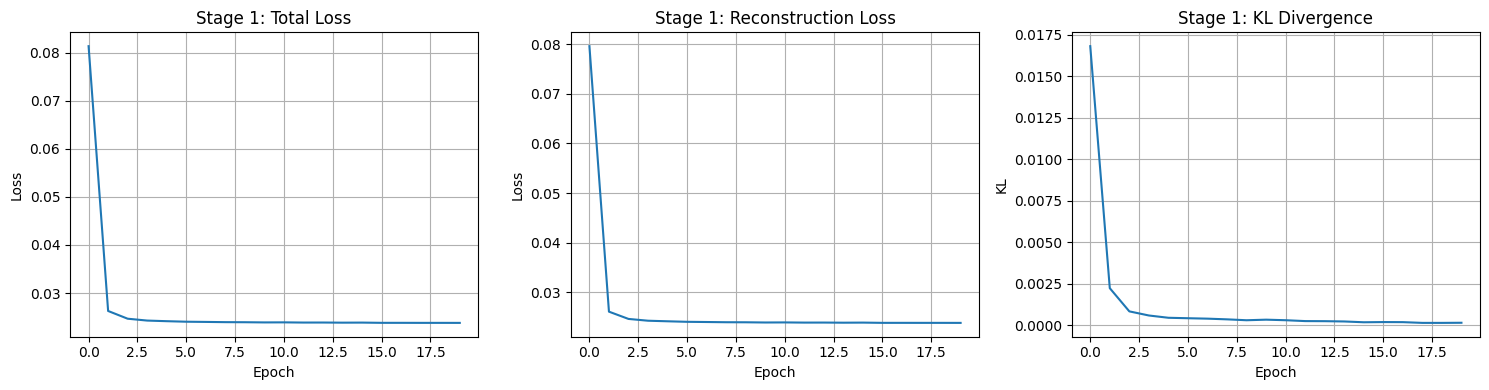

In [18]:
# Train Stage 1 (Warm Start)
stage1_losses, stage1_recon, stage1_kl = train_stage1(
    model, train_loader, 
    num_epochs=20, 
    lr=1e-3, 
    beta=0.1  # Small beta to avoid posterior collapse
)

# Plot Stage 1 losses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(stage1_losses)
axes[0].set_title('Stage 1: Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(stage1_recon)
axes[1].set_title('Stage 1: Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

axes[2].plot(stage1_kl)
axes[2].set_title('Stage 1: KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')
axes[2].grid(True)

plt.tight_layout()
plt.show()


STAGE 2: DGMM Fine-Tuning (Mixture Prior)


Epoch 1/30: 100%|██████████| 200/200 [00:03<00:00, 65.32it/s]


Epoch 1/30 | Loss: 1776844.517813 | Recon: 0.016455 | KL: 1776844.514219 | Avg Std: 0.519917


Epoch 2/30: 100%|██████████| 200/200 [00:02<00:00, 70.13it/s]


Epoch 2/30 | Loss: 86215.285547 | Recon: 0.005932 | KL: 86215.278457 | Avg Std: 0.091469


...

Epoch 28/30 | Loss: 317.017253 | Recon: 0.015177 | KL: 317.002076 | Avg Std: 0.002461


Epoch 29/30: 100%|██████████| 200/200 [00:02<00:00, 71.80it/s]


Epoch 29/30 | Loss: 302.823795 | Recon: 0.015403 | KL: 302.808392 | Avg Std: 0.002449


Epoch 30/30: 100%|██████████| 200/200 [00:02<00:00, 71.89it/s]


Epoch 30/30 | Loss: 291.553379 | Recon: 0.015798 | KL: 291.537581 | Avg Std: 0.002446
  DGMM weights: [0.04229627 0.32044345 0.2767377  0.1081747  0.25234792]
  Posterior variance: min=0.000000, max=0.001799


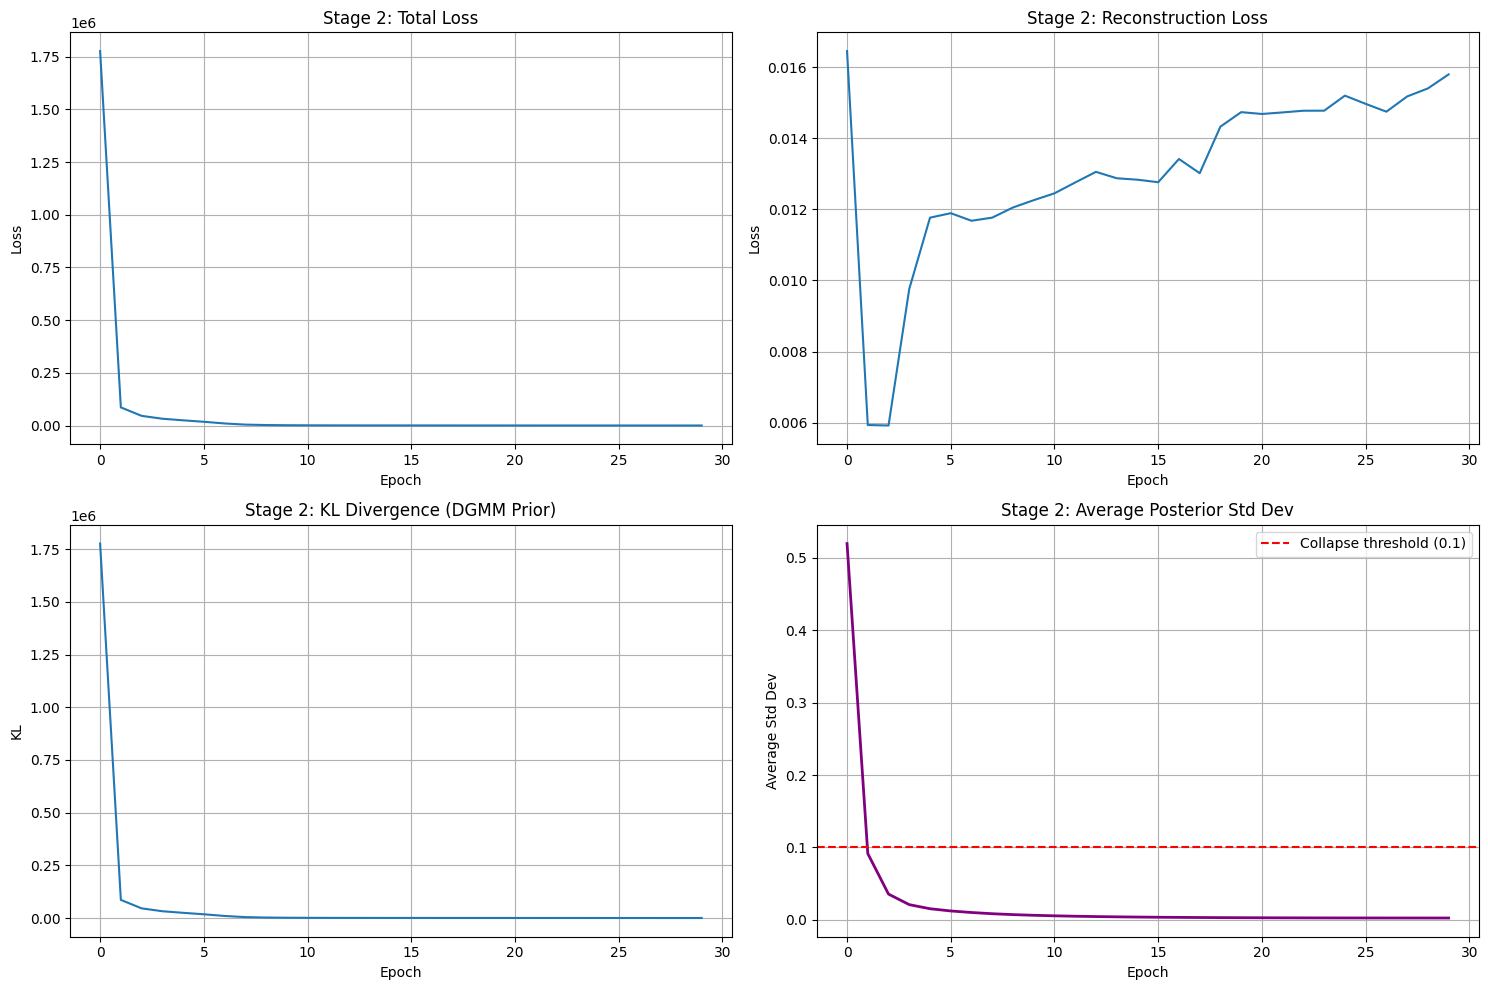


✅ Variance monitoring summary:
   Initial avg std: 0.519917
   Final avg std:   0.002446
   Min avg std:     0.002446
   ✗ WARNING: Variance may be collapsing


In [19]:
# Train Stage 2 (DGMM Fine-Tuning)
stage2_losses, stage2_recon, stage2_kl, stage2_stds = train_stage2(
    model, train_loader,
    num_epochs=30,
    lr=1e-4,
    beta=1.0  # Full weight on DGMM prior
)

# Plot Stage 2 losses
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(stage2_losses)
axes[0, 0].set_title('Stage 2: Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True)

axes[0, 1].plot(stage2_recon)
axes[0, 1].set_title('Stage 2: Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True)

axes[1, 0].plot(stage2_kl)
axes[1, 0].set_title('Stage 2: KL Divergence (DGMM Prior)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL')
axes[1, 0].grid(True)

axes[1, 1].plot(stage2_stds, linewidth=2, color='purple')
axes[1, 1].axhline(y=0.1, color='r', linestyle='--', label='Collapse threshold (0.1)')
axes[1, 1].set_title('Stage 2: Average Posterior Std Dev')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Average Std Dev')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f'\n✅ Variance monitoring summary:')
print(f'   Initial avg std: {stage2_stds[0]:.6f}')
print(f'   Final avg std:   {stage2_stds[-1]:.6f}')
print(f'   Min avg std:     {min(stage2_stds):.6f}')
if min(stage2_stds) > 0.01:
    print(f'   ✓ Variance NOT collapsed (healthy)')
else:
    print(f'   ✗ WARNING: Variance may be collapsing')

## 6. Evaluation and Anomaly Scoring

**Anomaly score:** `-log p_DGMM(z)`

Higher score = lower probability under mixture = more anomalous

In [20]:
def extract_latents_and_scores(model, loader, return_labels=False):
    """Extract latent representations and DGMM anomaly scores."""
    print('\nExtracting latents and computing anomaly scores...')
    
    model.eval()
    all_latents = []
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting'):
            if return_labels:
                x, labels = batch
                all_labels.append(labels)
            else:
                x = batch
            
            x = x.to(device)
            
            # Get latent (use mean, no sampling)
            windows = model.window_extractor(x)
            local_latents = model.partial_encoders(windows)
            z_concat = local_latents.view(x.size(0), -1)
            z = model.fc_mu(z_concat)  # Use mean for evaluation
            
            # Compute anomaly score: -log p(z)
            log_prob = model.dgmm.log_prob(z)
            scores = -log_prob  # Higher = more anomalous
            
            all_latents.append(z.cpu().numpy())
            all_scores.append(scores.cpu().numpy())
    
    latents = np.concatenate(all_latents, axis=0)
    scores = np.concatenate(all_scores, axis=0)
    
    if return_labels:
        labels = torch.cat(all_labels).numpy()
        return latents, scores, labels
    
    return latents, scores

# Extract from test data
Z_test, scores_test, y_test = extract_latents_and_scores(model, test_loader, return_labels=True)

# Convert labels to binary
y_test_binary = (y_test != 2).astype(int)

print(f'\nTest latents shape: {Z_test.shape}')
print(f'Test scores shape: {scores_test.shape}')
print(f'Normal pixels: {(y_test_binary == 0).sum():,}')
print(f'Anomaly pixels: {(y_test_binary == 1).sum():,}')


Extracting latents and computing anomaly scores...


Extracting: 100%|██████████| 200/200 [00:00<00:00, 200.89it/s]


Test latents shape: (204800, 64)
Test scores shape: (204800,)
Normal pixels: 201,601
Anomaly pixels: 3,199


In [21]:
# Compute metrics
roc_auc = roc_auc_score(y_test_binary, scores_test)
pr_auc = average_precision_score(y_test_binary, scores_test)

print('\n' + '='*70)
print('DGMM ANOMALY DETECTION PERFORMANCE')
print('='*70)
print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'PR-AUC:   {pr_auc:.4f}')
print('='*70)


DGMM ANOMALY DETECTION PERFORMANCE
ROC-AUC:  0.8666
PR-AUC:   0.5138


/tmp/ipykernel_20652/400097855.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


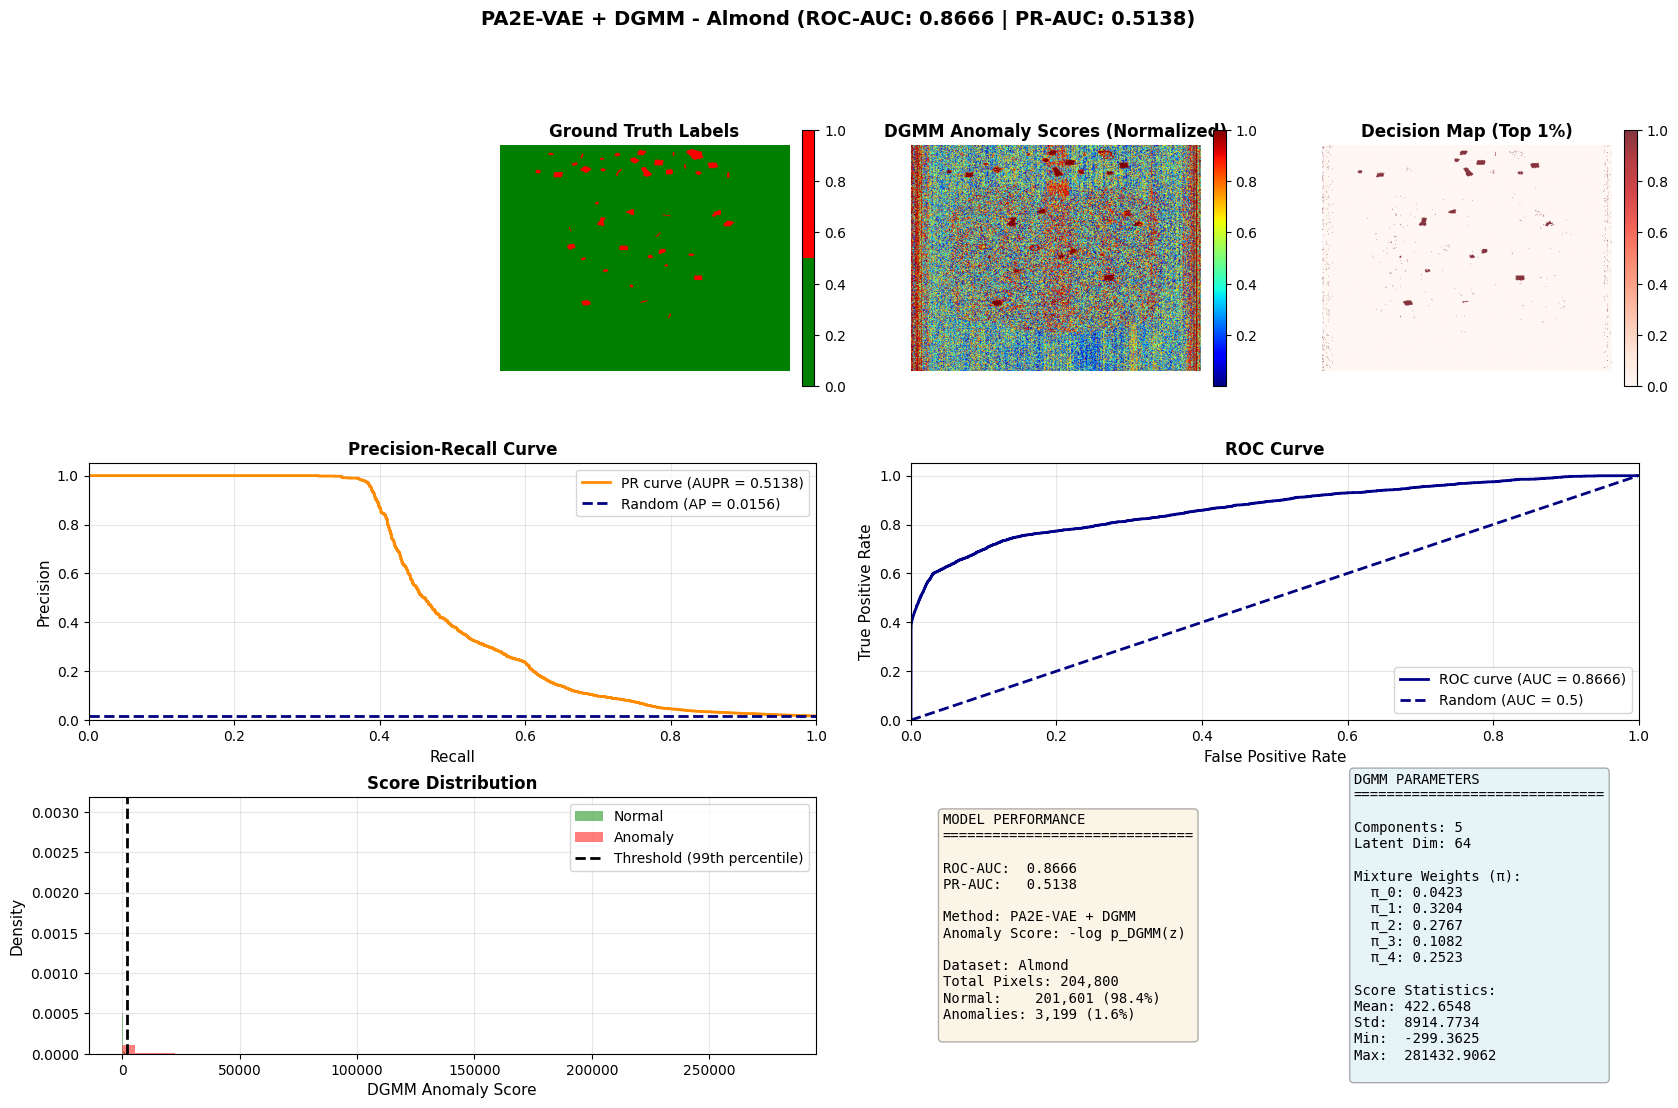


✅ Visualization complete!
   Top-K decision (1%): 2,048 pixels detected as anomalous


In [22]:
# Comprehensive visualization
from scipy.stats import rankdata

labels = y_test_binary
scores = scores_test

# Compute normalized rank scores
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im1 = ax1.imshow(label_map, cmap=cmap_binary)
ax1.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(normalized_score_map, cmap='jet')
ax2.set_title('DGMM Anomaly Scores (Normalized)', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 3])
im3 = ax3.imshow(decision_map, cmap='Reds', alpha=0.8)
ax3.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax4 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, scores)
ax4.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax4.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('Recall', fontsize=11)
ax4.set_ylabel('Precision', fontsize=11)
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, scores)
ax5.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax5.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('False Positive Rate', fontsize=11)
ax5.set_ylabel('True Positive Rate', fontsize=11)
ax5.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='lower right')
ax5.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax6 = fig.add_subplot(gs[2, 0:2])
ax6.hist(scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax6.hist(scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax6.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax6.set_xlabel('DGMM Anomaly Score', fontsize=11)
ax6.set_ylabel('Density', fontsize=11)
ax6.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E-VAE + DGMM
Anomaly Score: -log p_DGMM(z)

Dataset: {food_type}
Total Pixels: {len(scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax7.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax7.axis('off')

ax8 = fig.add_subplot(gs[2, 3])
pi, mu, var, _ = model.dgmm.get_params()
pi_np = pi.cpu().detach().numpy()
stats_text_right = f"""DGMM PARAMETERS
{'='*30}

Components: {model.dgmm.n_components}
Latent Dim: {model.dgmm.latent_dim}

Mixture Weights (π):
""" + "\n".join([f"  π_{k}: {pi_np[k]:.4f}" for k in range(len(pi_np))]) + f"""

Score Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}
"""
ax8.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax8.axis('off')

plt.suptitle(f'PA2E-VAE + DGMM - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

## 7. UMAP Visualization

Visualize how DGMM separates normal and anomalous pixels in latent space.

/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Generating UMAP visualization...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit complete. Shape: (204800, 2)


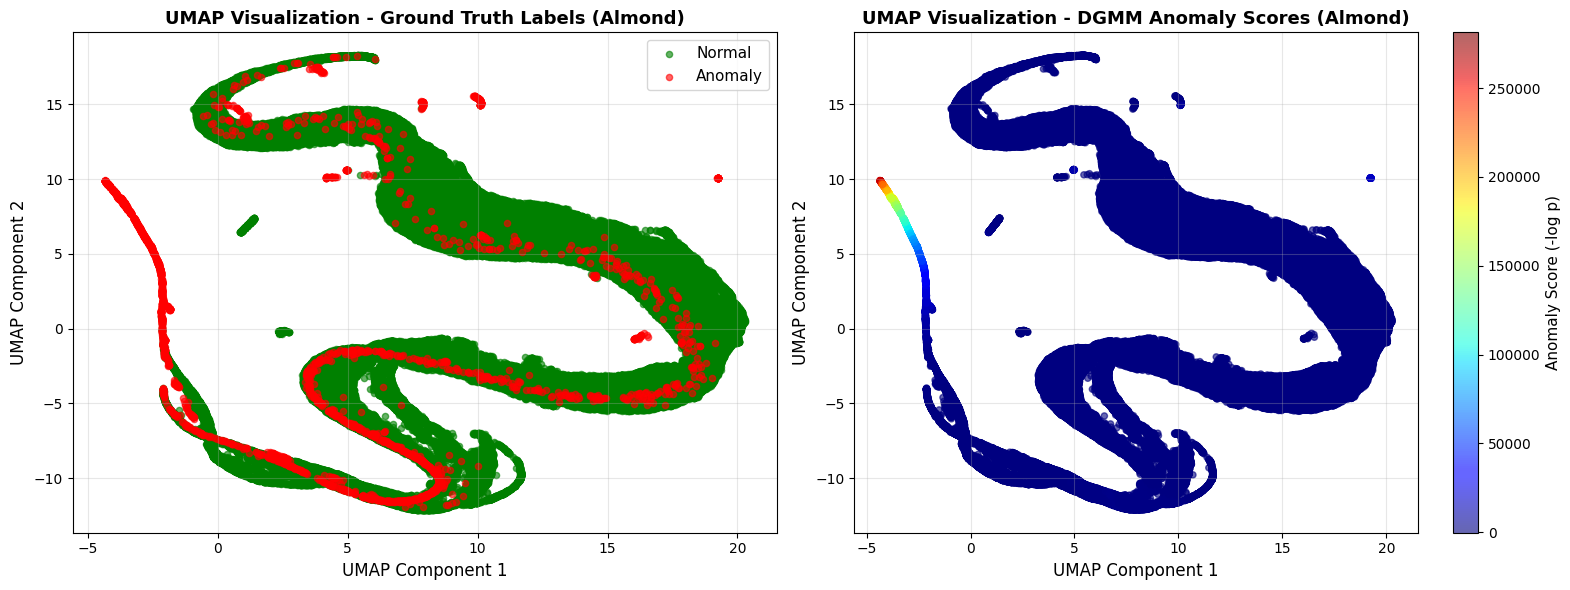


✅ UMAP visualization complete!
   Normal points (green): 201,601
   Anomaly points (red): 3,199


In [23]:
# UMAP Visualization
from umap import UMAP

print('\nGenerating UMAP visualization...')

# Fit UMAP
umap_reducer = UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
Z_test_umap = umap_reducer.fit_transform(Z_test)

print(f'UMAP fit complete. Shape: {Z_test_umap.shape}')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: UMAP colored by ground truth
ax1 = axes[0]
scatter1 = ax1.scatter(Z_test_umap[y_test_binary == 0, 0], 
                       Z_test_umap[y_test_binary == 0, 1],
                       c='green', label='Normal', alpha=0.6, s=20)
scatter2 = ax1.scatter(Z_test_umap[y_test_binary == 1, 0], 
                       Z_test_umap[y_test_binary == 1, 1],
                       c='red', label='Anomaly', alpha=0.6, s=20)
ax1.set_xlabel('UMAP Component 1', fontsize=12)
ax1.set_ylabel('UMAP Component 2', fontsize=12)
ax1.set_title(f'UMAP Visualization - Ground Truth Labels ({food_type})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: UMAP colored by DGMM anomaly score
ax2 = axes[1]
scatter3 = ax2.scatter(Z_test_umap[:, 0], Z_test_umap[:, 1],
                       c=scores_test, cmap='jet', alpha=0.6, s=20)
ax2.set_xlabel('UMAP Component 1', fontsize=12)
ax2.set_ylabel('UMAP Component 2', fontsize=12)
ax2.set_title(f'UMAP Visualization - DGMM Anomaly Scores ({food_type})', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter3, ax=ax2)
cbar.set_label('Anomaly Score (-log p)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n✅ UMAP visualization complete!')
print(f'   Normal points (green): {(y_test_binary == 0).sum():,}')
print(f'   Anomaly points (red): {(y_test_binary == 1).sum():,}')

## 8. Save Model and Results

In [24]:
# Save model and results
save_dir = '.'
model_path = f'{save_dir}/pa2e_dgmm_{food_type.lower()}.pth'
results_path = f'{save_dir}/pa2e_dgmm_results_{food_type.lower()}.json'

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'input_dim': input_dim,
        'n_gmm_components': model.dgmm.n_components,
        'window_size': 56,
        'stride': 14,
        'hidden_dim': 128,
        'latent_local_dim': 32,
        'latent_global_dim': 64
    },
    'dgmm_params': {
        'logits': model.dgmm.logits.cpu().detach().numpy().tolist(),
        'means': model.dgmm.means.cpu().detach().numpy().tolist(),
        'logvars': model.dgmm.logvars.cpu().detach().numpy().tolist()
    }
}, model_path)

# Save results
pi, mu, var, _ = model.dgmm.get_params()
results_data = {
    'dataset': food_type,
    'method': 'PA2E-VAE + DGMM',
    'metrics': {
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc)
    },
    'dgmm': {
        'n_components': model.dgmm.n_components,
        'latent_dim': model.dgmm.latent_dim,
        'mixture_weights': pi.cpu().detach().numpy().tolist()
    }
}

with open(results_path, 'w') as f:
    json.dump(results_data, f, indent=2)

print(f'\n✅ Model and results saved:')
print(f'   Model: {model_path}')
print(f'   Results: {results_path}')


✅ Model and results saved:
   Model: ./pa2e_dgmm_almond.pth
   Results: ./pa2e_dgmm_results_almond.json


## 9. Comparison with PostHoc GMM

Load and compare results from PostHoc GMM notebook.

In [25]:
# Compare with PostHoc GMM results
posthoc_results_path = f'./pa2e_posthoc_gmm_results_{food_type.lower()}.json'

if os.path.exists(posthoc_results_path):
    with open(posthoc_results_path, 'r') as f:
        posthoc_results = json.load(f)
    
    print('\n' + '='*70)
    print('COMPARISON: PostHoc GMM vs DGMM')
    print('='*70)
    print(f'\nPostHoc GMM:')
    print(f'  ROC-AUC: {posthoc_results["metrics"]["roc_auc"]:.4f}')
    print(f'  PR-AUC:  {posthoc_results["metrics"]["pr_auc"]:.4f}')
    
    print(f'\nDGMM (End-to-End):')
    print(f'  ROC-AUC: {roc_auc:.4f}')
    print(f'  PR-AUC:  {pr_auc:.4f}')
    
    print(f'\nImprovement:')
    roc_diff = roc_auc - posthoc_results["metrics"]["roc_auc"]
    pr_diff = pr_auc - posthoc_results["metrics"]["pr_auc"]
    print(f'  Δ ROC-AUC: {roc_diff:+.4f}')
    print(f'  Δ PR-AUC:  {pr_diff:+.4f}')
    print('='*70)
else:
    print(f'\n⚠️  PostHoc GMM results not found: {posthoc_results_path}')


COMPARISON: PostHoc GMM vs DGMM

PostHoc GMM:
  ROC-AUC: 0.9561
  PR-AUC:  0.6818

DGMM (End-to-End):
  ROC-AUC: 0.8666
  PR-AUC:  0.5138

Improvement:
  Δ ROC-AUC: -0.0895
  Δ PR-AUC:  -0.1680


## Summary

**What we built:**
- End-to-end trainable VAE with DGMM prior
- No post-hoc fitting, no sklearn
- Mixture becomes the latent prior

**Why it works better:**
- Encoder learns to map each material to its own Gaussian
- Anomalies get pushed between Gaussians → low density
- Correct tail probabilities → better AUPRC

**Key insight:**
> "That pixel is close to grass in Euclidean space,
> but its spectral signature doesn't match the grass Gaussian."
> 
> → Kicked out of every Gaussian → low density → anomaly